На основе представленного датасета будем решать задачу классификации. Попытаемся прогнозировать конверсию, т.е. потратит пользователь деньги на цифровые услуги или нет. Целевая колонка Conversion бинарная, соответственно и классификация бинарная.

Представленные в датасете данные не имеют пропусков, что нормально для маркетинговой аналитики на цифровых платформах. Будем смотреть на выбросы,корреляцию данных, вариативность и пробовать разные модели классификации.


In [1]:
import phik as phik
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Загрузка данных


In [28]:
df = pd.read_csv("./digital_marketing_campaign_dataset.csv", sep=",")

### Основная информация о данных


In [5]:
print("df shape =", df.shape)
df.head()

df shape = (8000, 20)


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [4]:
df.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


### Может ли колонка CustomerID быть индексом


In [17]:
df = df.set_index("CustomerID", inplace=False)

### Работа с цифровыми колонками

-   Отделить цифровые колонки
-   Посмотреть и оценить корреляции (очень желательно не одним исследованием)
-   Провести оценку выбросов
-   Оценить изменчивость относительно таргета

Самостоятельный поиск способов дополнительной оценки цифровых признаков


In [40]:
df_numerics = df[df._get_numeric_data().columns]
df_numerics.head()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,8000,56,136912,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,8001,69,41760,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1
2,8002,46,88456,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1
3,8003,32,44085,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,1
4,8004,60,83964,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,1


In [21]:
# pd.plotting.scatter_matrix(
#     df_numerics, figsize=(15, 15), diagonal="kde"
# )
# plt.show()

In [36]:
df[["CustomerID", "Conversion"]]

,CustomerID,Conversion
0,8000,1
1,8001,1
2,8002,1
3,8003,1
4,8004,1
...,...,...
7995,15995,0
7996,15996,0
7997,15997,1
7998,15998,1


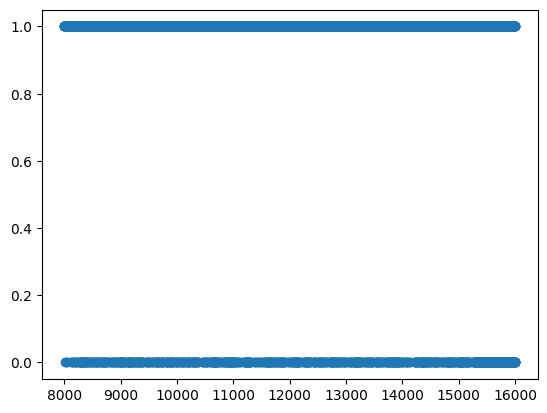

In [41]:
plt.scatter(df["CustomerID"], df["Conversion"])

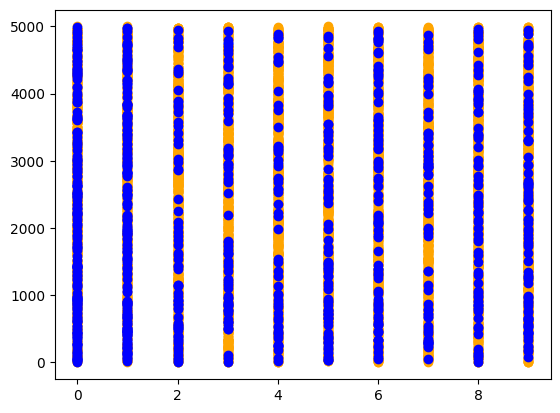

In [27]:
plt.scatter(
    df[df["Conversion"] == 1]["PreviousPurchases"],
    df[df["Conversion"] == 1]["LoyaltyPoints"],
    color="orange",
    label="Pay",
)
plt.scatter(
    df[df["Conversion"] == 0]["PreviousPurchases"],
    df[df["Conversion"] == 0]["LoyaltyPoints"],
    color="blue",
    label="Don't pay",
)

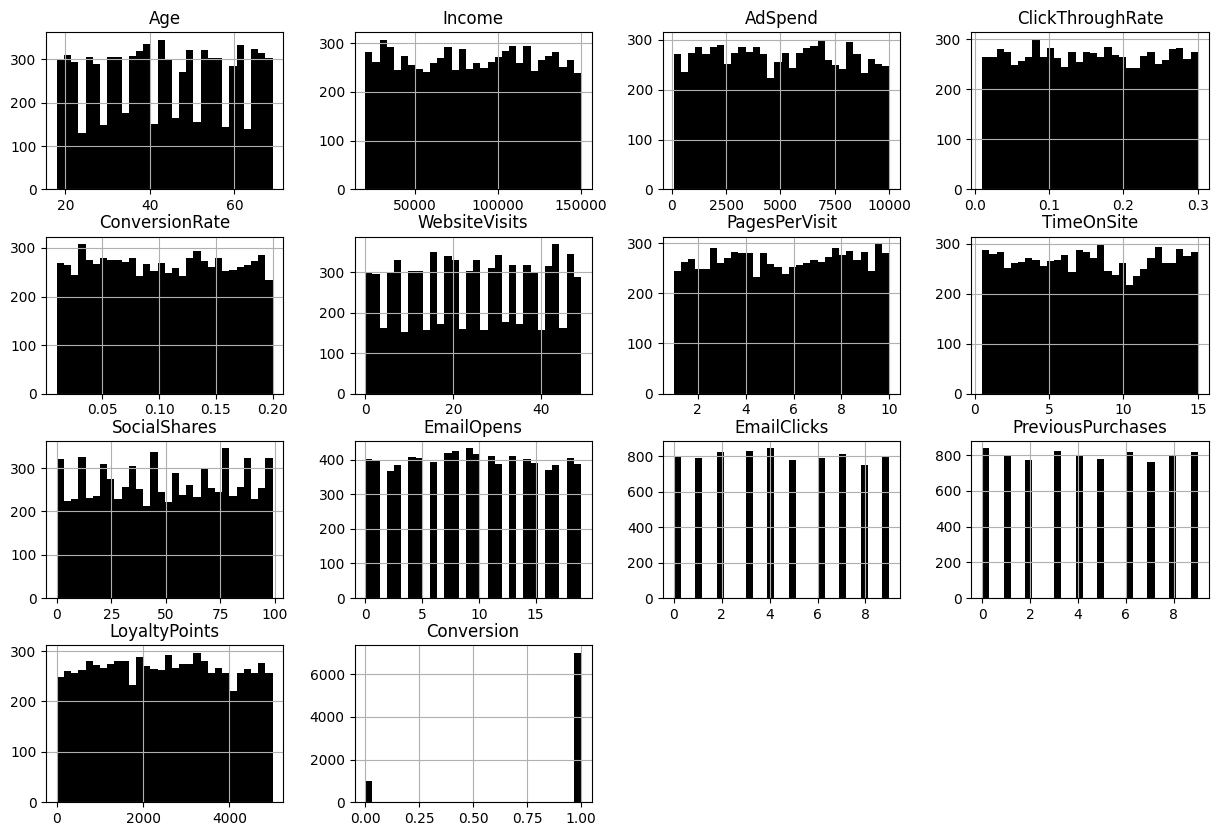

In [19]:
df_numerics.hist(color="k", bins=30, figsize=(15, 10))
plt.show()

In [ ]:
numerics = ["int64", "float64"]
df_numerics = df.select_dtypes(include=numerics)

### Работа с категориальными признаками

-   Отделить категориальные колонки
-   Оценить изменчивость относительно таргета

Самостоятельный поиск способов дополнительной оценки цифровых признаков


In [51]:
categorial_cols = list(set(df.columns) - set(df._get_numeric_data().columns))
print(categorial_cols)

['CampaignChannel', 'AdvertisingPlatform', 'CampaignType', 'AdvertisingTool', 'Gender']


In [52]:
for col in df[categorial_cols].columns:
    print(df[col].value_counts())
    print("\n")

CampaignChannel
Referral        1719
PPC             1655
Email           1557
SEO             1550
Social Media    1519
Name: count, dtype: int64


AdvertisingPlatform
IsConfid    8000
Name: count, dtype: int64


CampaignType
Conversion       2077
Awareness        1988
Consideration    1988
Retention        1947
Name: count, dtype: int64


AdvertisingTool
ToolConfid    8000
Name: count, dtype: int64


Gender
Female    4839
Male      3161
Name: count, dtype: int64




In [61]:
df.drop(['AdvertisingPlatform', 'AdvertisingTool'], axis=1, inplace=True)
categorial_cols = list(set(df.columns) - set(df._get_numeric_data().columns))
print(categorial_cols)

['Gender', 'CampaignChannel', 'CampaignType']


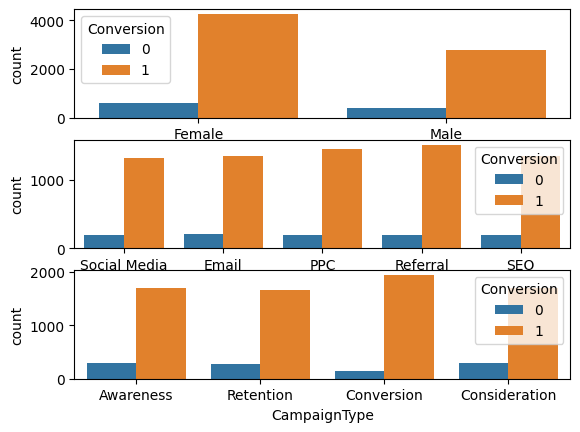

In [65]:
fig, ax = plt.subplots(len(categorial_cols), 1)
for i in range(len(categorial_cols)):
    sns.countplot(x=categorial_cols[i], hue="Conversion", data=df, ax=ax[i])

### Разделение данных на признаки и таргет

Оценка баланса классов


### Построение модели классификатора на базе логистической регрессии

-   Использование конвейера обязательно
-   Подобрать оптимальные параметры модели
-   Нарисовать Confusion Matrix
-   Получить оценки Precision, Recall
-   Построить PR кривую
-   Посчитать AUC


### Построение модели SVM классификатора

-   Использование конвейера обязательно
-   Подобрать оптимальные параметры модели
-   Нарисовать Confusion Matrix
-   Получить оценки Precision, Recall
-   Построить PR кривую
-   Посчитать AUC


### Построение модели KNN классификатора

-   Использование конвейера обязательно
-   Подобрать оптимальные параметры модели
-   Нарисовать Confusion Matrix
-   Получить оценки Precision, Recall
-   Построить PR кривую
-   Посчитать AUC


### Обязательно оценить все модели не только на F1-Score, но и на AUC. Выбрать модель. Обосновать выбор. Провести дополнительное тестирование модели на тех же данных с использованием cross-validation
